## Ce notebook est consacré à l'analyse pour faire ressortir les potentiels problématiques métier  ainsi que les visualisations

pour cette phase analyse il n'y a pas une liste de questions universelles à poser

Ce qui guide l'analyse, c'est toujours le métier derrière la donnée.


Pour ce notebook consacré au dataset coffee_sales, la logique métier ici se base sur le commerce

On cherche donc la rentabilité:

Les questions naturelles qui peuvent être posées sont:

Quels produits génèrent le chiffre d'affaires ?

Quel jour vend-on le plus ?


In [1]:
import pandas as pd

In [22]:
sales = pd.read_csv("../datasets/coffee_sales_clean.csv")

# exercice 1: aggrégation avec groupby()

 
# Chiffre d'affaires total par produit 
print("chiffre d'affaires total par produit")
ca_par_produit = sales.groupby('coffee_name')["money"].sum()
print(ca_par_produit.sort_values(ascending=False))
print("\n")

# nombre de ventes par produit
print("nombres de vente par produits")
vente_par_produit = sales.groupby('coffee_name')["money"].count()
print(vente_par_produit.sort_values(ascending=False))
print("\n")

# Prix moyen par produit 
print("prix moyen de chaque produit")
prix_moyen = sales.groupby('coffee_name')['money'].mean()
print(prix_moyen.sort_values(ascending=False).round(2))
print("\n")


# Plusieurs agrégations en une seule fois 
resume = sales.groupby('coffee_name')['money'].agg(['sum','mean','count']) 
resume.columns = ['CA total', 'Prix moyen', 'Nb ventes'] 
print(resume.sort_values('CA total', ascending=False)) 

chiffre d'affaires total par produit
coffee_name
Latte                  27866.30
Americano with Milk    25269.12
Cappuccino             18034.14
Americano              15062.26
Hot Chocolate          10172.46
Cocoa                   8678.16
Cortado                 7534.86
Espresso                2814.28
Name: money, dtype: float64


nombres de vente par produits
coffee_name
Americano with Milk    824
Latte                  782
Americano              578
Cappuccino             501
Cortado                292
Hot Chocolate          282
Cocoa                  243
Espresso               134
Name: money, dtype: int64


prix moyen de chaque produit
coffee_name
Hot Chocolate          36.07
Cappuccino             36.00
Cocoa                  35.71
Latte                  35.63
Americano with Milk    30.67
Americano              26.06
Cortado                25.80
Espresso               21.00
Name: money, dtype: float64


                     CA total  Prix moyen  Nb ventes
coffee_name            

## Exercice 1 — Agrégations avec groupby()

**Ce que j'ai fait :**

Regroupé les ventes par produit avec groupby() pour calculer le CA total,

Le nombre de ventes et le prix moyen par café.


**Pourquoi je l'ai fait :**

Une ligne = une vente. 3636 transactions individuelles ne disent rien seules.
    
Le produit est la dimension naturelle d'un dataset de ventes — c'est la première

question à poser avant d'analyser quand ou comment on vend.


**Ce que ça m'a appris :**

Le classement par volume et le classement par CA ne coïncident pas.

Americano with Milk est le plus vendu (824 ventes) mais le Latte génère

le plus de CA (27 866€). Le prix moyen est la variable qui explique cet écart :

35,63€ pour le Latte contre 30,67€ pour l'Americano with Milk.

In [8]:
# exercice 2: analyse temporelle - vente par mois

sales = pd.read_csv("../datasets/coffee_sales_clean.csv")

print(sales.dtypes,"\n")

sales['date'] = pd.to_datetime(sales['date'])

# Extraire des informations temporelles
sales['mois'] = sales['date'].dt.month
sales['jour_semaine'] = sales['date'].dt.day_name()

 
# Chiffre d'affaires total par mois 
ca_par_mois = sales.groupby('mois')['money'].sum().reset_index()
print(ca_par_mois,"\n")


# nombre de ventes par jour de la semaine
vente_par_jour = sales.groupby("jour_semaine")['money'].count().reset_index()
vente_par_jour.columns = ['jour_semaine', 'nb_ventes']
print(vente_par_jour.sort_values('nb_ventes', ascending=False))
print("\n")
 
# Quel mois a le CA le plus élevé ? 
print('Meilleur mois :', ca_par_mois.loc[ca_par_mois['money'].idxmax()]) 

date            object
datetime        object
cash_type       object
card            object
money          float64
coffee_name     object
dtype: object 

    mois     money
0      1   6398.86
1      2  13215.48
2      3  17036.64
3      4   6720.56
4      5   9063.42
5      6   7758.76
6      7   6915.94
7      8   7613.84
8      9   9988.64
9     10  13891.16
10    11   8590.54
11    12   8237.74 

  jour_semaine  nb_ventes
5      Tuesday        585
1       Monday        561
0       Friday        544
4     Thursday        520
6    Wednesday        510
2     Saturday        482
3       Sunday        434


Meilleur mois : mois         3.00
money    17036.64
Name: 2, dtype: float64


## Exercice 2 — Analyse temporelle des ventes


**Ce que j'ai fait :**

Extrait le mois et le jour de la semaine depuis la colonne date,

Puis calculé le CA par mois et le nombre de ventes par jour

avec groupby().


**Pourquoi je l'ai fait :**

Les colonnes mois et jour_semaine préparées en semaine 2 permettent

de passer d'une vision ligne par ligne à une vision temporelle.

Une vente individuelle ne dit rien sur les tendances — regrouper

par période révèle la saisonnalité et les habitudes de la clientèle.


**Ce que ça m'a appris :**

Deux constats distincts ressortent.


Sur le CA mensuel : mars est le meilleur mois (17 036€) et octobre

le deuxième (13 891€). Les mois d'été sont uniformément bas autour

de 7 500€. La fréquentation varie selon les périodes de l'année.

Sur les jours de semaine : la clientèle est majoritairement

une clientèle de semaine. Les 5 jours ouvrables dépassent tous

les 500 ventes, le dimanche est le jour le plus faible (434 ventes)

soit 74% du volume du mardi.

    
# Note technique : renommer la colonne après count() est indispensable
    
# garder le nom 'money' pour un nombre de ventes est trompeur.

In [13]:
# exercice 3: top 5 et filtrage

sales = pd.read_csv("../datasets/coffee_sales_clean.csv") 

#top 5 produits par chiffre d'affaires --- 
top5_produits = sales.groupby('coffee_name')['money'].sum().nlargest(5) 
print('Top 5 produits par CA :') 
print(top5_produits,"\n") 

# ici ce sont les 5 produits qui rapportent le plus d'argent, à ne pas confondre avec les 
# produits qui se vendent le plus en termes de volume.

top5_produits_quantité = sales.groupby('coffee_name')['money'].count().nlargest(5) 
print('Top 5 produits qui se vendent le mieux :') 
print(top5_produits_quantité) 

Top 5 produits par CA :
coffee_name
Latte                  27866.30
Americano with Milk    25269.12
Cappuccino             18034.14
Americano              15062.26
Hot Chocolate          10172.46
Name: money, dtype: float64 

Top 5 produits qui se vendent le mieux :
coffee_name
Americano with Milk    824
Latte                  782
Americano              578
Cappuccino             501
Cortado                292
Name: money, dtype: int64


## Exercice 3 — Top 5 et filtrage (Coffee Sales)

**Ce que j'ai fait :**

Identifié les 5 produits qui génèrent le plus de CA avec

groupby() + sum() + nlargest(5), puis les 5 produits les plus

vendus en volume avec groupby() + count() + nlargest(5).


**Pourquoi je l'ai fait :**

Sur 8 produits et 3636 ventes, nlargest(5) permet d'isoler

Immédiatement les produits dominants sans parcourir l'ensemble.

Séparer CA et volume est nécessaire — un seul classement

mélange deux réalités différentes.

    
**Ce que ça m'a appris :**

Les deux classements ne coïncident pas. Les 4 mêmes produits

apparaissent dans les deux top 5 mais dans un ordre différent.

Le Cortado est dans le top 5 volume mais absent du top 5 CA.

Le Hot Chocolate fait l'inverse — present dans le top 5 CA,

absent du top 5 volume. Volume et valeur sont deux lectures

complémentaires du même dataset, pas interchangeables.

In [2]:
import matplotlib.pyplot as plt 

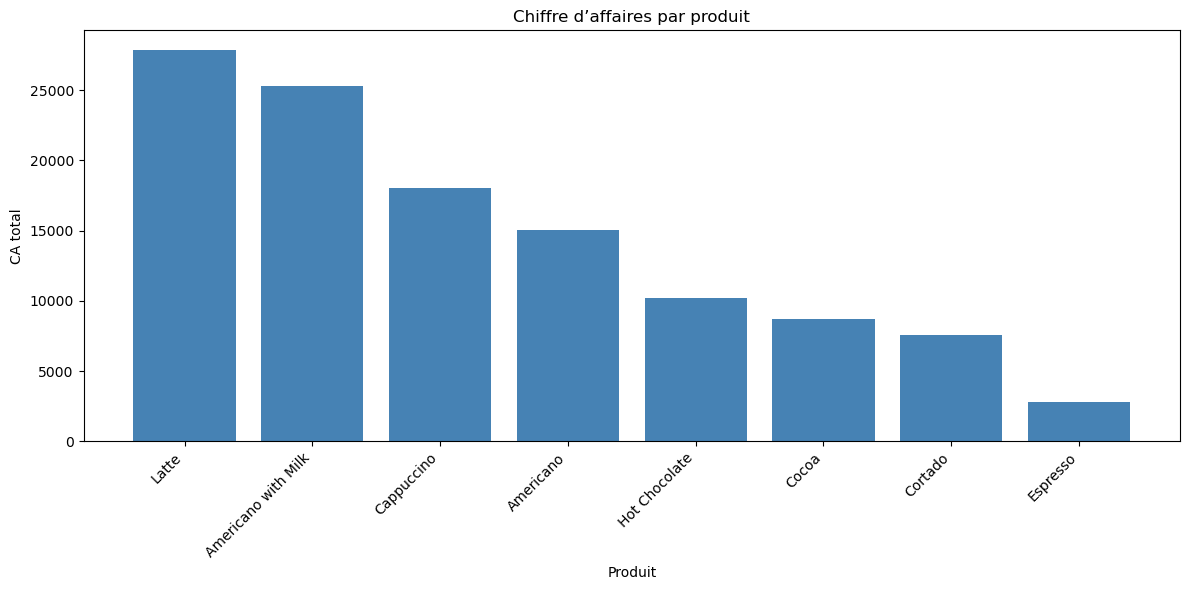

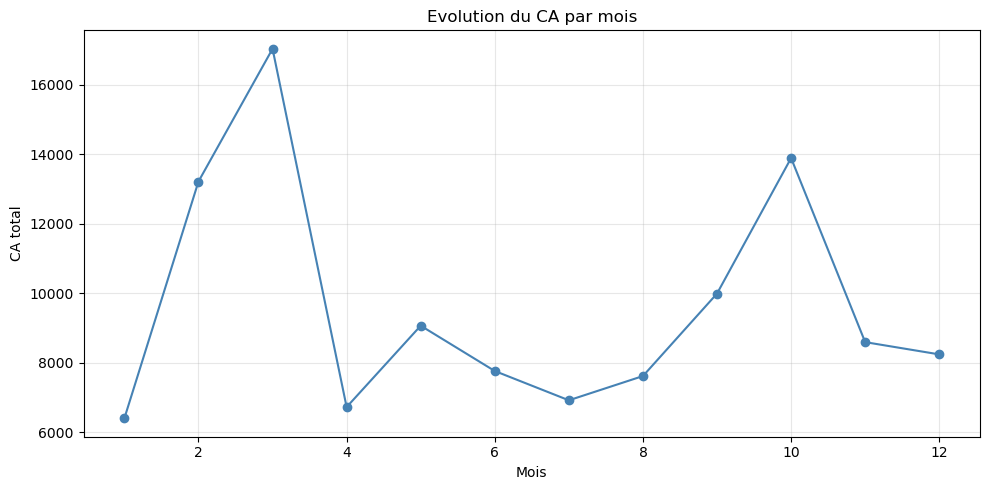

In [3]:
# Exercice 4 : premiers graphiques avec Matplotlib

sales = pd.read_csv('../datasets/coffee_sales_clean.csv') 
sales['date'] = pd.to_datetime(sales['date']) 
sales['mois'] = sales['date'].dt.month

 
##  Bar chart : CA par produit 
ca_par_produit = sales.groupby('coffee_name')['money'].sum().sort_values(ascending=False) # Calcul du CA par produit, trié du plus grand au plus petit
                                                                                          # sort_values(ascending=False) : on veut voir les meilleurs en premier
 
plt.figure(figsize=(12, 6)) # Définit la taille du graphique en pouces (largeur 12, hauteur 6)
                            # Sans ça, la figure par défaut est trop petite pour 8 produits

plt.bar(ca_par_produit.index, ca_par_produit.values, color='steelblue') # ca_par_produit.index : les noms des produits → axe X
                                                                        # ca_par_produit.values : les montants → hauteur des barres (axe Y)
                                                                         # color='steelblue' : couleur uniforme pour ne pas distraire du message
# Titre du graphique
plt.title('Chiffre d’affaires par produit') 
# Labels des axes — indispensables pour savoir ce qu'on lit
plt.xlabel('Produit') 
plt.ylabel('CA total') 

plt.xticks(rotation=45, ha='right') # Incline les noms de produits à 45 degrés pour éviter le chevauchement
                                    # ha='right' : aligne le texte à droite du point de rotation → reste lisible

plt.tight_layout() # Recalcule les marges automatiquement pour que rien ne soit coupé
                   # À utiliser systématiquement dès qu'il y a des labels inclinés

plt.savefig('../visuals/chiffre d_affaires_par_produit.png') # Exporte le graphique en .png dans le dossier visuals/
                                                             # Toujours avant plt.show() — après show(), la figure est vidée
plt.show() 



## Line chart : CA par mois 
ca_par_mois = sales.groupby('mois')['money'].sum().reset_index() 
 
plt.figure(figsize=(10, 5)) 
plt.plot(ca_par_mois['mois'], ca_par_mois['money'], marker='o', color='steelblue') 
plt.title('Evolution du CA par mois') 
plt.xlabel('Mois') 
plt.ylabel('CA total') 
plt.grid(True, alpha=0.3) # Affiche une grille en arrière-plan pour faciliter la lecture des valeurs
                          # True : active la grille
                          # alpha=0.3 : transparence à 30% — discrète pour ne pas concurrencer les données
plt.tight_layout() 
plt.savefig('../visuals/ca_par_mois.png') 
plt.show() 

## Exercice 4 — Premiers graphiques avec Matplotlib (Coffee Sales)

**Ce que j'ai fait :**
Visualisé le CA par produit avec un bar chart et l'évolution

du CA par mois avec un line chart. Les deux graphiques sont

exportés dans le dossier visuals/.

    
**Pourquoi je l'ai fait :**
Les agrégations de l'exercice 1 et 2 donnaient des chiffres

lisibles en tableau. La visualisation traduit ces mêmes

résultats en image — un bar chart classe les produits en un

coup d'œil, un line chart montre la tendance mensuelle sans

avoir à lire 12 lignes de chiffres.

    
**Ce que ça m'a appris :**
    
Matplotlib suit toujours la même logique dans le même ordre :

définir la taille, tracer, ajouter titre et labels, ajuster

les marges, exporter, afficher. Le choix du type de graphique

n'est pas esthétique — il dépend de ce qu'on compare.

Catégories entre elles : bar chart. Évolution dans le temps :

line chart. savefig() doit toujours précéder show() — après

show() la figure est vidée et l'export serait vide.

In [4]:
import seaborn as sns 

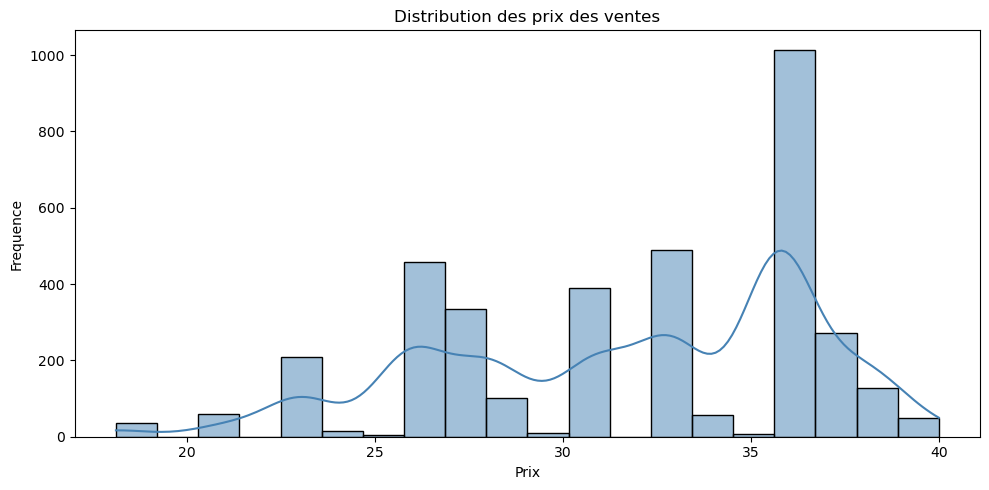

In [8]:
# exercice 5: visualisation statistiques avec seaborn

sales = pd.read_csv('../datasets/coffee_sales_clean.csv') 
 
##  Histogramme : distribution des prix 
plt.figure(figsize=(10, 5)) 
sns.histplot(sales['money'], bins=20, color='steelblue', kde=True) # bins=20 : découpe les valeurs en 20 tranches — plus bins est grand, plus le découpage est fin
                                                                   # color='steelblue' : couleur uniforme des barres
                                                                   # kde=True : ajoute une courbe de densité par-dessus l'histogramme
                                                                   #Elle montre la forme de la distribution plus clairement que les barres seules
plt.title('Distribution des prix des ventes') 
plt.xlabel('Prix') 
plt.ylabel('Frequence') 
plt.tight_layout() 
plt.savefig('../visuals/distribution_prix_des_cafés.png') 
plt.show() 

### Lecture — Distribution des prix des ventes

# L'axe X = le prix,
# l'axe Y = le nombre de ventes à ce prix | combien de ventes tombent dans chaque tranche de prix ?


La distribution est multimodale — plusieurs pics distincts

apparaissent sur l'axe X, ce qui signifie qu'il n'y a pas

un prix dominant mais plusieurs groupes de prix fixes.



Pic principal autour de 36€ — plus de 1000 ventes.

Ce sont les cafés premium : Hot Chocolate, Cappuccino, Latte.


Deuxième groupe autour de 26€ — environ 450 ventes.

Troisième groupe autour de 30-32€ — environ 400 ventes.

En dessous de 22€ — très peu de ventes, correspond à l'Espresso.



La courbe KDE confirme cette forme irrégulière — elle monte
et descend plusieurs fois au lieu de former une cloche symétrique.



Constat : les prix ne sont pas continus. Ils se regroupent

naturellement autour de valeurs fixes — logique pour un coffee

shop où chaque produit a un prix catalogue.

## Exercice 5 — Visualisations statistiques avec Seaborn

**Ce que j'ai fait :**

Créé un histogramme de la distribution des prix sur Coffee Sales

et un boxplot de la fréquentation par type de jour sur Transilien

avec Seaborn.


**Pourquoi je l'ai fait :**

Les agrégations donnent des moyennes et des totaux — elles

résument mais cachent la forme des données. L'histogramme

montre comment les valeurs se répartissent sur leur plage

entière. Le boxplot montre les quartiles et les outliers

qu'on ne voit pas dans un simple groupby.


**Ce que ça m'a appris :**

Deux constats distincts.

- Sur Coffee Sales : la distribution des prix est multimodale —

plusieurs pics fixes correspondant aux prix catalogue de chaque

produit. Les données ne sont pas continues ni aléatoires.

    
- Sur Transilien : les boîtes sont plates et proches de zéro sur

les trois types de jours — la majorité des tranches horaires

sont calmes. Ce sont quelques heures de pointe qui concentrent

l'essentiel du trafic, encore plus marqué en JOB avec des

outliers à 47 000 voyageurs. Le boxplot traduit visuellement

le CV de 279% observé avec describe() en semaine 1 —

la boucle est bouclée entre exploration et visualisation.